### How would you know about till how many epochs should i run my model so that it does not Overfit?
### You can stop updating after a certain no. of epochs using Early Stopping

In [27]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pylab import rcParams
import warnings
from mlxtend.plotting import plot_decision_regions
from matplotlib.colors import ListedColormap
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles
import seaborn as sns

In [28]:
X,y = make_circles(n_samples=100, noise=0.1, random_state=1)

<Axes: >

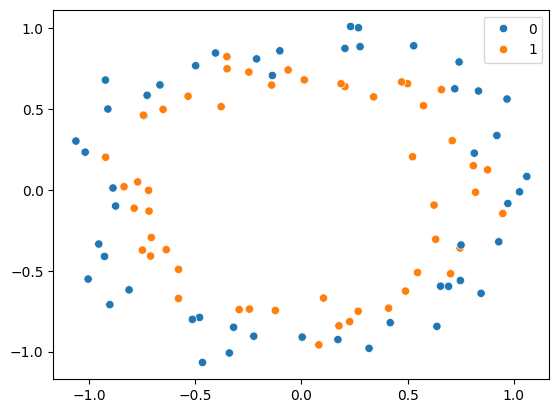

In [29]:
# Seaborn does NOT accept positional arguments for x and y like Matplotlib does
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y)  # Seaborn - (keyword-only arguments)
# plt.scatter(X[:,0], X[:,1], c=y)    # Matplotlib - (allows positional arguments)

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=2)

In [31]:
model = Sequential()

model.add(Dense(256, activation='relu', input_dim=2))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [32]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [33]:
history = model.fit(X_train, y_train, validation_data=(X_test,y_test), epochs=3500, verbose=0)

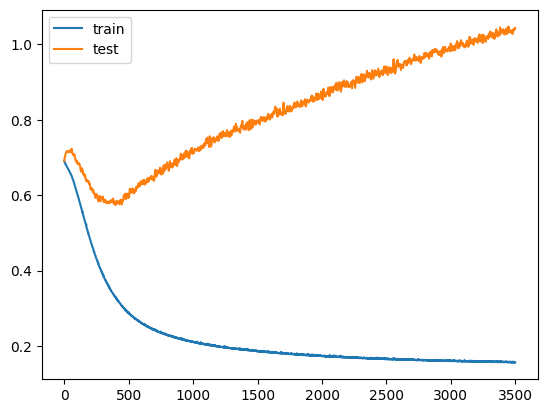

In [34]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step


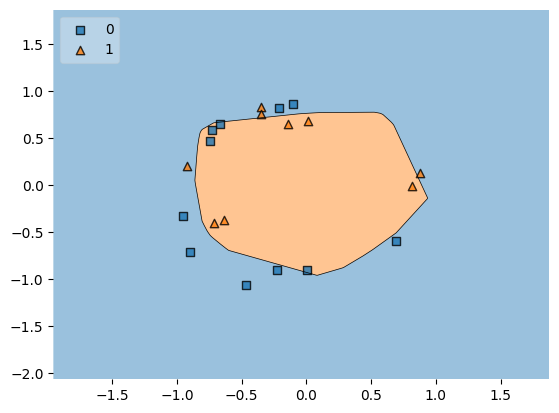

In [35]:
plot_decision_regions(X_test, y_test.ravel(), clf=model, legend=2)
plt.show()

# Apply Early Stopping

In [49]:
model = Sequential()

model.add(Dense(256, activation='relu', input_dim=2))
model.add(Dense(1, activation='sigmoid'))

In [50]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [53]:
callback = EarlyStopping(
    monitor="val_loss",  # If val_loss stops improving training may stop.
    min_delta=0.00001,   # It means validation loss must reduce by at least 0.00001
    patience=40,   # Even if the model doesn’t improve, wait for given no. of (here=40) more epochs
    verbose=1,     # Show a message when training stops
    mode="auto",   # For val_loss, lower is better and For val_accuracy, higher is better
    baseline=None, # No fixed target value
    restore_best_weights=False, # Model keeps the weights from the last epoch
)

In [54]:
history = model.fit(X_train, y_train, validation_data=(X_test,y_test), epochs=3500, callbacks=callback)

Epoch 1/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.5836 - loss: 0.6702 - val_accuracy: 0.4500 - val_loss: 0.7120
Epoch 2/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.6148 - loss: 0.6559 - val_accuracy: 0.4500 - val_loss: 0.7130
Epoch 3/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.6500 - loss: 0.6554 - val_accuracy: 0.4500 - val_loss: 0.7137
Epoch 4/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.6109 - loss: 0.6669 - val_accuracy: 0.4500 - val_loss: 0.7139
Epoch 5/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5828 - loss: 0.6658 - val_accuracy: 0.3500 - val_loss: 0.7150
Epoch 6/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5945 - loss: 0.6578 - val_accuracy: 0.3500 - val_loss: 0.7166
Epoch 7/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.6539 - loss: 0.6535 - val_accuracy: 0.3500 - val_loss: 0.7175
Epoch 8/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.6203 - loss: 0.6585 - val_accuracy: 0.3000 - v

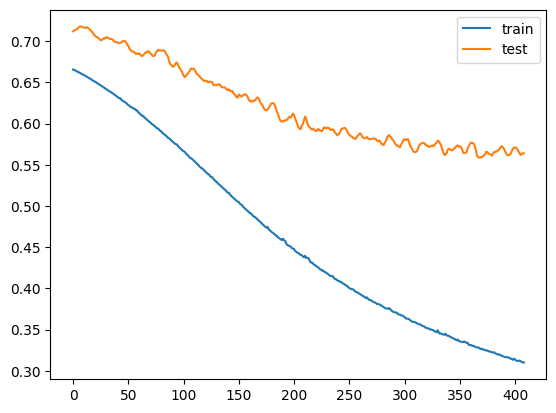

In [55]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step


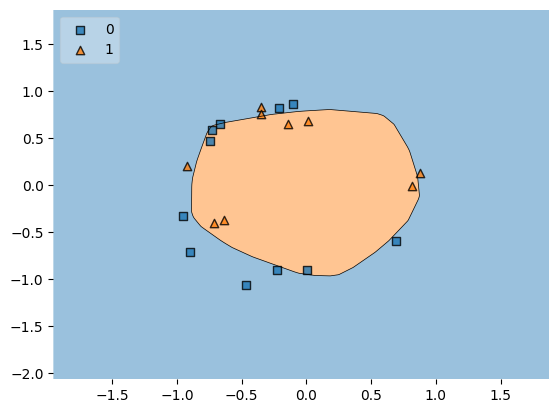

In [56]:
plot_decision_regions(X_test, y_test.ravel(), clf=model, legend=2)
plt.show()